# Interaction Effect Experiment
While modeling, typically we try to learn F(X) based on optimizing an error metric. A modeling algorithm may or may not capture all interactions present in the data. 

**Define Interaction:**
F(X) exhibits interaction between two of more of its variables X = {x_i, x_j, ... x_n} if perturbing the space of covariate a `x_i` or any combination of multivariate attributes changes the prediction power of F(X).

\begin{align}
E_{x}[\frac{\partial^2 F(X))}{\partial x_{i}\partial x_{j}}]^2 > 0
\end{align}

From our research, it seemed pretty natural to enable graphical interpretation on low cardinality subset of fetures using Partial Depdence Plot(PDP)(_used by Friedman in 2001_) and Independent Component Expectation(ICE). Hence, MLI in DAI has an extensive support to bring in "human in the loop" using some the technique mentioned earlier.

PDP or ICE still has constraints to capture interaction beyond 3 dimensions. In-order to come around that, we have been exploring to H-Statistics(a statistical test using partial dependence) as a technique to compute interactions for all combinations.

To test the interaction between 2 defined variables part of the modeling process:
\begin{align}
H^2_{jk} = \frac{\sum_{i=1}^{N} [\widehat{F_{jk}}(x_{ij}, x_{ik}) - \widehat{F_{j}}(x_{ij}) -  \widehat{F_{k}}(x_{ik})]^2}{\sum_{i=1}^{N} \widehat{F_{jk}^2}(x_{ij}, x_{ik})}
\end{align}

## 1. Data Loading
We will be using iris dataset for this experiment. The dataset contains 150 rows and 4 features. It's a multi-class classification problem(_3 unique class categories_)

In [8]:
import time
from sklearn import datasets
from sklearn import ensemble
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

import lightgbm as lgb

from mli.explanation.h_statistic import HStatistic


iris_data = datasets.load_iris()
print(iris_data.DESCR)

X = iris_data.data
y = iris_data.target
print("\n\n\n")
print(f"Original data shape: {X.shape}")

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

## 2. Train and Test split

In [12]:
# Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set shape {X_train.shape}")
print(f"Test set shape {X_test.shape}")

num_train, num_feature = X_train.shape
print(f"Number of features: {num_feature}")
print("----------------------------------")
print(f"Name of the features: {iris_data.feature_names}")
print("----------------------------------")
print(f"Number of classes(multi-class problem): {np.unique(y)}")

Train set shape (120, 4)
Test set shape (30, 4)
Number of features: 4
----------------------------------
Name of the features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
----------------------------------
Number of classes(multi-class problem): [0 1 2]


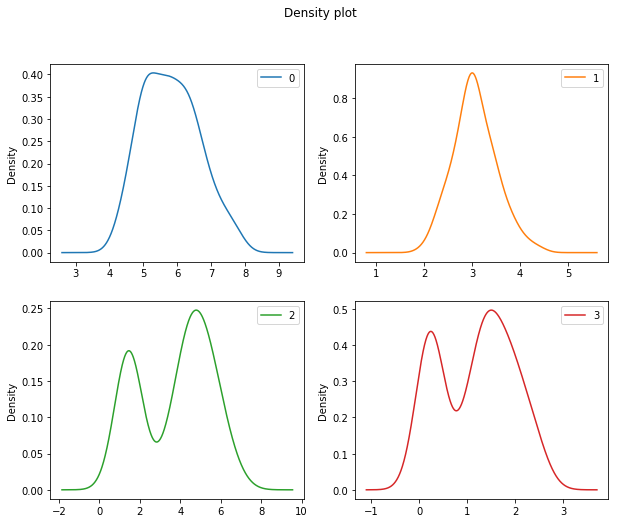

In [90]:
# density plot to understand the distribution of the features
import matplotlib.pyplot as plt
data_train = pd.DataFrame(X_train)
data_train.plot(kind='density', subplots=True, layout=(2, 2), figsize=(10, 8), title="Density plot", sharex=False)
plt.show()

## 3. Modeling
Modeling stage is divided into 2 parts
1. vanilla lightgbm
2. DAI based automate model

In [19]:
# First just using lightgbm
lgb_train = lgb.Dataset(X_train, y_train, free_raw_data=False)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train, free_raw_data=False)

# generate feature names
feature_name = iris_data.feature_names

# specify your configurations as a dict
params = {
    'boosting_type': 'gbdt',
    'objective': 'multiclass',
    'metric': 'multi_logloss', # since it's a multi-class problem
    'num_class':3,
    'num_leaves': 31,
    'learning_rate': 0.07,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}

In [ ]:
print('Starting training phase ...')
# feature_name and categorical_feature
gbm = lgb.train(params,
                lgb_train,
                num_boost_round=40,
                valid_sets=lgb_train,  # eval training data
                feature_name=feature_name)

## 4. Model Evaluation

In [24]:
from sklearn.metrics import mean_squared_error, f1_score

y_pred = gbm.predict(X_test)
y_class = [np.argmax(x_i) for x_i in y_pred]

# eval with loaded model
print("The rmse of trained model's prediction:", mean_squared_error(y_test, np.array(y_class)) ** 0.5)
print("The F1 Score on trained model's prediction:", f1_score(y_test, y_class, average='micro'))

The rmse of trained model's prediction: 0.0
The F1 Score on trained model's prediction: 1.0


In [34]:
## Relative Feature ranking
max_val = np.max(gbm.feature_importance(importance_type='split'))
relative_importance = [float(v)/max_val for v in gbm.feature_importance()]

feature_rank = pd.DataFrame(relative_importance).T
feature_rank.columns = feature_name

result = feature_rank.T.sort_values([0], ascending=False)
print(result)

                          0
petal length (cm)  1.000000
petal width (cm)   0.862903
sepal length (cm)  0.370968
sepal width (cm)   0.258065


## 5. Interpretation

### 5.1 Computing Interactions

In [35]:
def predict_prob(x, class_index=0):
    # Multi-class use-case
    return pd.DataFrame(gbm.predict(x)[:, class_index])

In [36]:
# train
X_train_df = pd.DataFrame(X_train, columns=feature_name)
# test
X_test_df = pd.DataFrame(X_test, columns=feature_name)

predict_prob(X_train_df.loc[0])

,0
0,0.948185


In [37]:
X_train_df = pd.DataFrame(X_train, columns=feature_name)
interactions = HStatistic("H-stat for pairs").explain(
            feature_name,
            X_train_df,
            predict_method=predict_prob)

In [84]:
# Sorted Ordering of the interactions
def rank_interaction(interaction_dict, reverse=True):
    for key, value in sorted(interaction_dict.items(), key=lambda x:x[1]['p_0'], reverse=True):
        print(f"Feature Interaction: {key}/ H-Statistics score: {value}")

In [85]:
rank_interaction(interactions.explanations())

Feature Interaction: ('petal length (cm)', 'petal width (cm)')/ H-Statistics score: {'p_0': 0.02554235620140376}
Feature Interaction: ('sepal width (cm)', 'petal width (cm)')/ H-Statistics score: {'p_0': 0.015609010964447834}
Feature Interaction: ('sepal length (cm)', 'sepal width (cm)')/ H-Statistics score: {'p_0': 0.006993004956004079}
Feature Interaction: ('sepal width (cm)', 'petal length (cm)')/ H-Statistics score: {'p_0': 0.0055732583308931785}
Feature Interaction: ('sepal length (cm)', 'petal width (cm)')/ H-Statistics score: {'p_0': 0.002657827997981897}
Feature Interaction: ('sepal length (cm)', 'petal length (cm)')/ H-Statistics score: {'p_0': 0.00047986475827894076}


## 6. DAI Model

### 6.1. Connect to DAI instance

In [79]:
# Using the latest release DAI-1.5.1
# Step 1: Upload the data to DAI engine
import requests
import math
import os
import pandas as pd
from h2oai_client import Client, ModelParameters, InterpretParameters

In [ ]:
import os

ip = 'prerelease.h2o.ai'
username = 'h2oai'
# use environment variables or secure credential stores
password = os.getenv('H2O_PASSWORD', 'h2oai')  # Default for local testing only

h2oai = Client(address = 'http://' + ip, username=username, password=password)

# info about the DAI Client:
print(h2oai.address)

### 6.2. Upload dataset to Driverless AI

In [81]:
feature_list = feature_name + ['target']
print(feature_list)


# train
data_df_train = pd.DataFrame(data=np.c_[X_train, y_train],
                         columns=feature_list)
print(data_df_train.head(2))

# test
data_df_test = pd.DataFrame(data=np.c_[X_test, y_test],
                         columns=feature_list)
print(data_df_test.head(2))


# persist the dataframes
data_df_train.to_csv("iris_train.csv", index=False)
data_df_test.to_csv("iris_test.csv", index=False)

current_directory = os.getcwd()
print(current_directory)
train_path_dai = f"{current_directory}/iris_train.csv"
test_path_dai = f"{current_directory}/iris_test.csv"

# Upload datasets
train = h2oai.upload_dataset_sync(train_path_dai)
test = h2oai.upload_dataset_sync(test_path_dai)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                4.6               3.6                1.0               0.2   
1                5.7               4.4                1.5               0.4   

   target  
0     0.0  
1     0.0  
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                6.1               2.8                4.7               1.2   
1                5.7               3.8                1.7               0.3   

   target  
0     1.0  
1     0.0  
/home/ubuntu/h2o/mli-2


### 6.3. Set up parameters for Driverless AI experiment

In [ ]:
# Set the parameters you want to pass to DAI
dataset_key=train.key # Dataset to use for DAI
validset_key='' # Validation set to use for DAI (Note, we are not using one for this experiment)
testset_key=test.key # Test set to use for DAI
target="target" # Target column for DAI
# dropped_cols=["sample_weight"] #List of columns to drop. In this case we are dropping 'sample_weight'
weight_col=None # The column that indicates the per row observation weights.
                # If None, each row will have an observation weight of 1
fold_col=None # The column that indicates the fold. If None, the folds will be determined by DAI

is_time_series=False # Whether or not the experiment is a time series problem
is_classification=True # Inform DAI if the problem type is a classification (binomial/multinomial)
                    # or not (regression)

enable_gpus=True # Whether or not to enable GPUs
seed=1234 # Use seed for reproducibility
scorer_str='logloss' # Set evaluation metric. In this case we are interested in optimizing R-squared
accuracy=1 # Accuracy setting for experiment (One of the 3 knobs you see in the DAI UI)
time=1 # Time setting for experiment (One of the 3 knobs you see in the DAI UI)
interpretability=2 # Interpretability setting for experiment (One of the 3 knobs you see in the DAI UI)
config_overrides=None # Extra parameters that can be passed in TOML format

In [ ]:
experiment = h2oai.start_experiment_sync(
    #Datasets
    dataset_key=dataset_key,
    validset_key = validset_key,
    testset_key=testset_key,

    #Columns
    target_col=target,
    #cols_to_drop=dropped_cols,
    weight_col=weight_col,
    fold_col=fold_col,

    #Parameters
    is_classification=is_classification,
    enable_gpus=enable_gpus,
    seed=seed,
    accuracy=accuracy, # DAI suggested for accuracy
    time=time, # DAI suggested for time
    interpretability=interpretability, # DAI suggested for interpretability
    scorer=scorer_str,
    # Extra parameters that can be passed in TOML format
    config_overrides=None
)

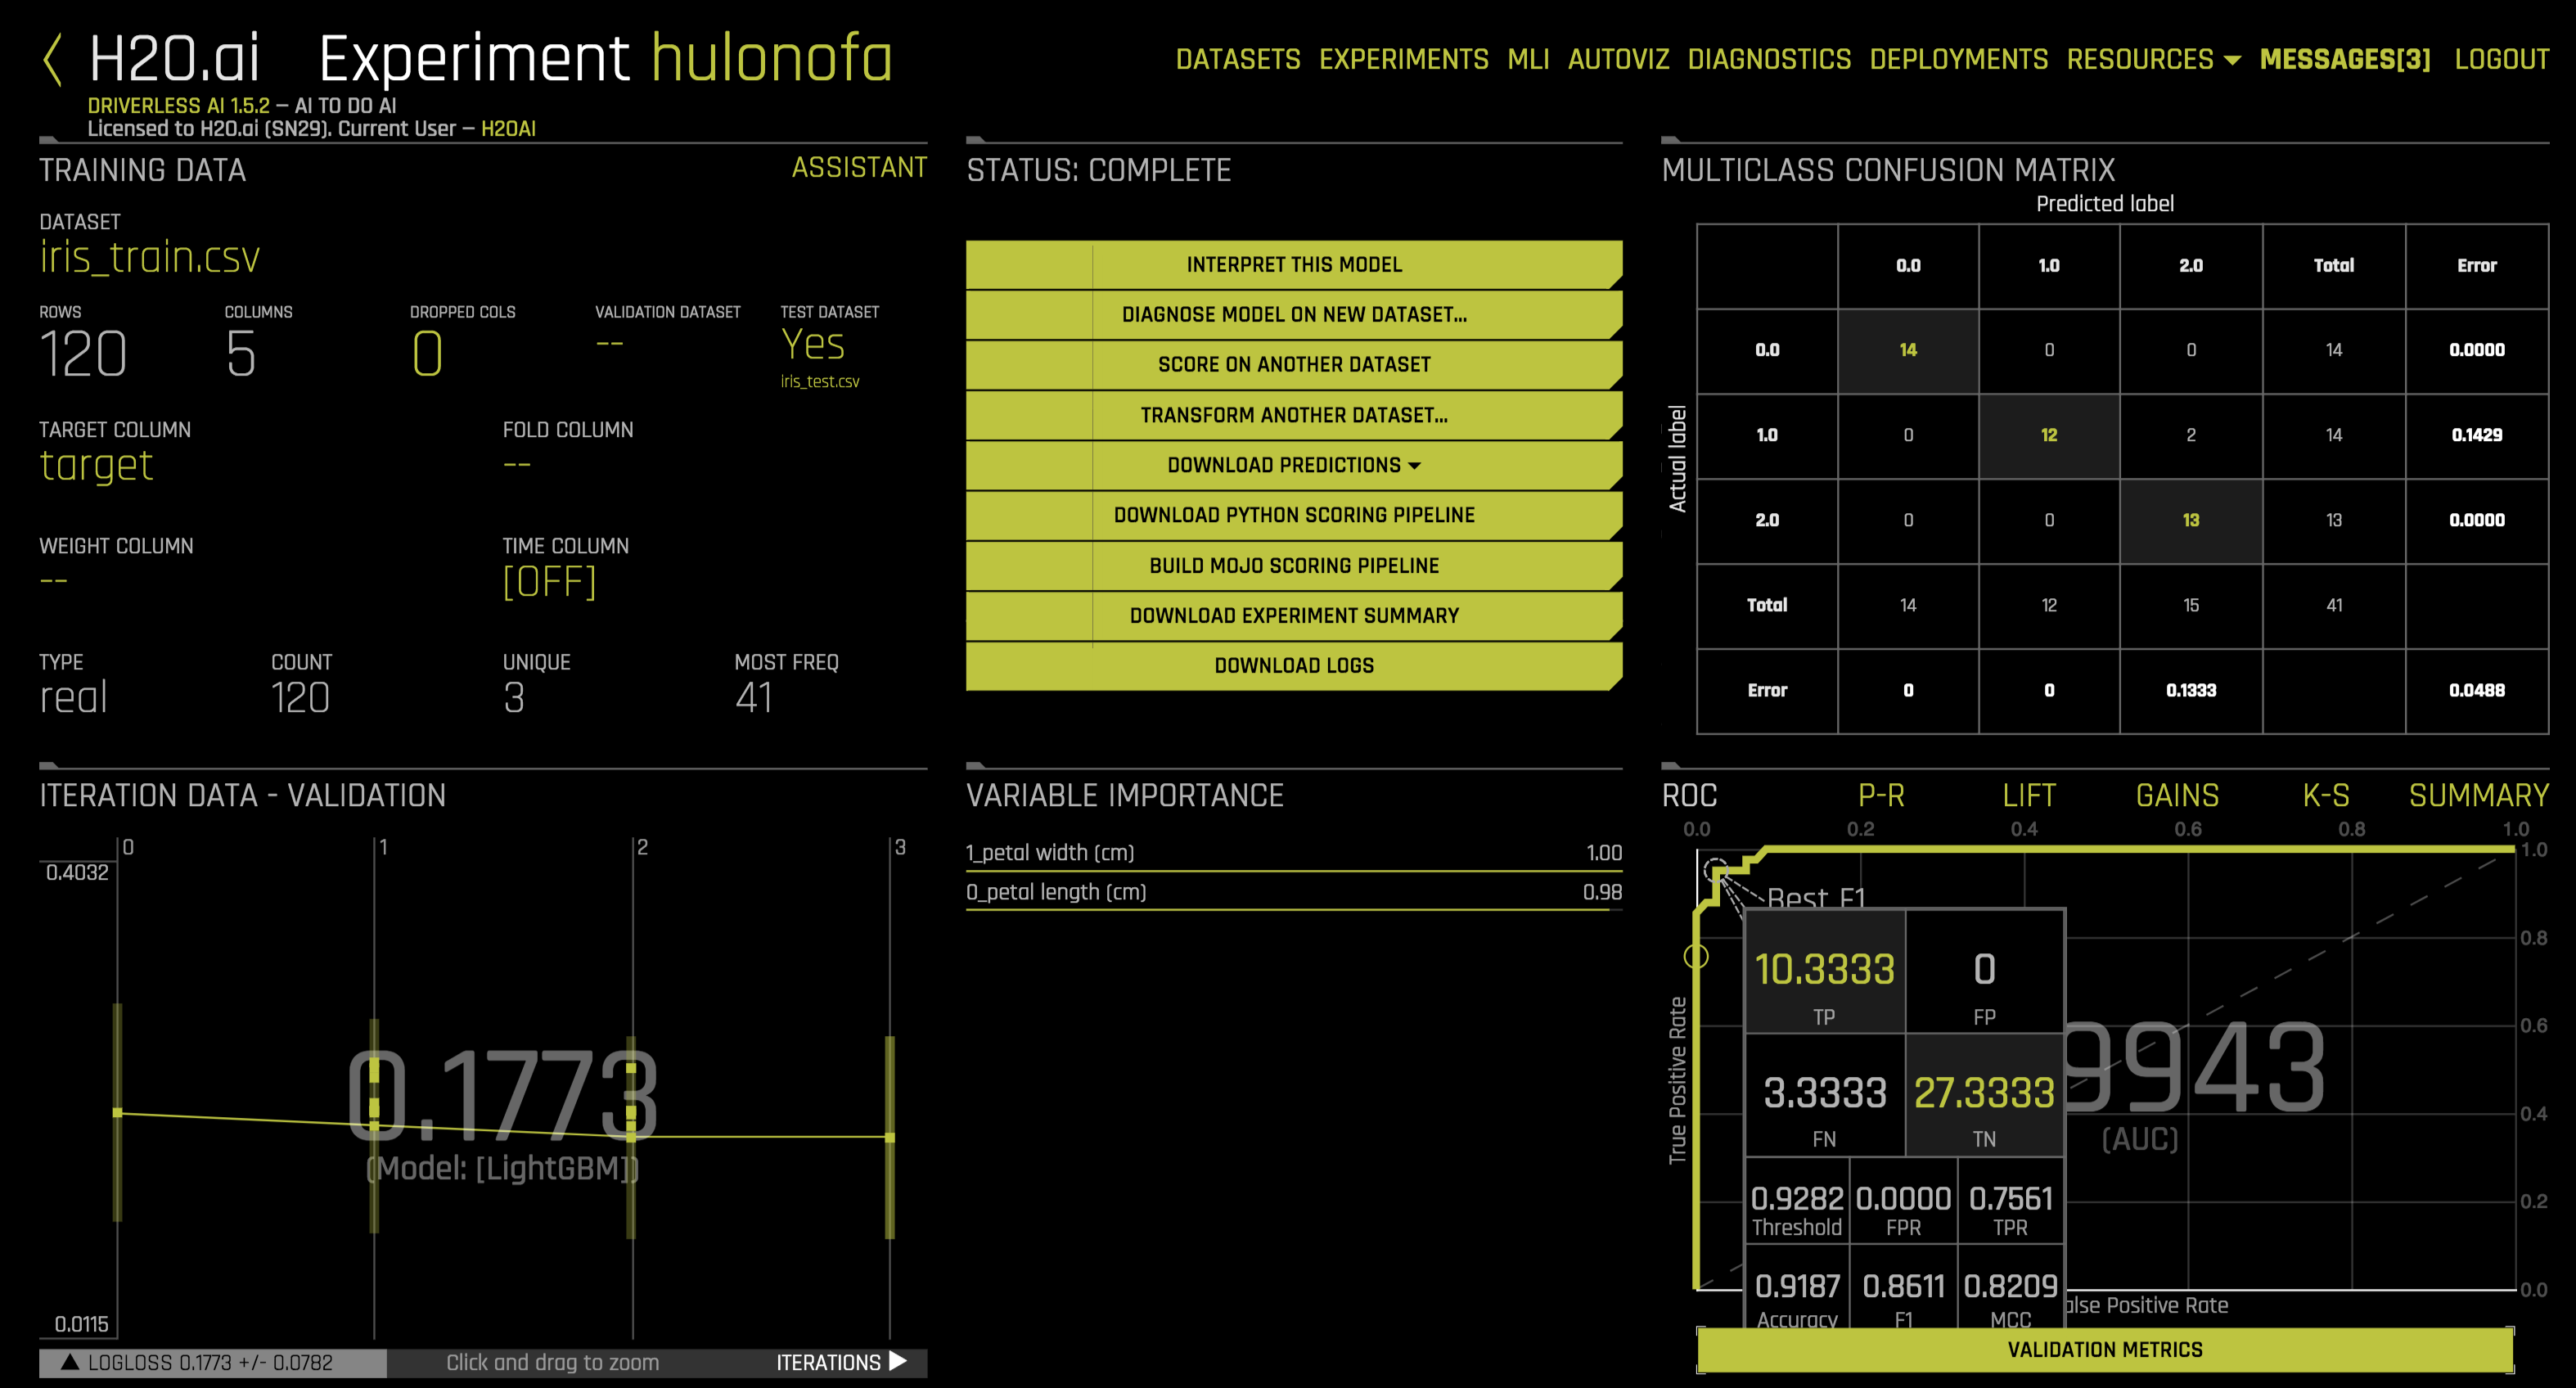

In [88]:
from IPython.display import Image
Image("img/DAI_experiment_screen.png")

#### Quick Summary:

In [65]:
print(f"Name of the experiment: {experiment.description}")

# Download Summary
import subprocess
summary_path = h2oai.download(src_path=experiment.summary_path, dest_dir=".")
dir_path = "./h2oai_experiment_summary_" + experiment.key
subprocess.call(['unzip', '-o', summary_path, '-d', dir_path], shell=False)

# View Features
features = pd.read_table(dir_path + "/features.txt", sep=',', skipinitialspace=True)
features.head()

Name of the experiment: lusehidi


,Relative Importance,Feature,Description
0,1.00000,9_InteractionAdd:petal length (cm):petal width...,[petal length (cm)] + [petal width (cm)]
1,0.76396,3_ClusterDist3:petal width (cm).1,Distances to cluster center after segmenting c...
2,0.43968,3_ClusterDist3:petal width (cm).2,Distances to cluster center after segmenting c...
3,0.35761,3_ClusterDist3:petal width (cm).0,Distances to cluster center after segmenting c...
4,0.17399,18_InteractionDiv:petal length (cm):petal widt...,[petal length (cm)] / [petal width (cm)]


### 6.4. Set up scoring package from Driverless AI experiment

In [67]:
h2oai.download(experiment.scoring_pipeline_path, '.')

'./scorer.zip'

In [83]:
# unpack
from shutil import unpack_archive
unpack_archive('scorer.zip', '.')

In [80]:
#Import scoring module
!python -m pip install scoring-pipeline/scoring_h2oai_experiment_*.whl

You are using pip version 9.0.3, however version 19.0.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


### 6.5. Computing interactions on DAI model

In [89]:
from scoring_h2oai_experiment_lusehidi import Scorer

In [90]:
%%capture
# Create a singleton Scorer instance.
# For optimal performance, create a Scorer instance once, and call score() or score_batch() multiple times.
scorer = Scorer()

In [92]:
import datatable as dt
def predict_dt(X):
    X = dt.Frame(X)
    return scorer.score_batch(X).iloc[:, 0]

In [93]:
interactions = HStatistic("H-stat for pairs on DAI models").explain(
            feature_name,
            X_train_df,
            predict_method=predict_dt)

In [89]:
rank_interaction(interactions.explanations())

Feature Interaction: ('petal length (cm)', 'petal width (cm)')/ H-Statistics score: {'p_0': 0.02554235620140376}
Feature Interaction: ('sepal width (cm)', 'petal width (cm)')/ H-Statistics score: {'p_0': 0.015609010964447834}
Feature Interaction: ('sepal length (cm)', 'sepal width (cm)')/ H-Statistics score: {'p_0': 0.006993004956004079}
Feature Interaction: ('sepal width (cm)', 'petal length (cm)')/ H-Statistics score: {'p_0': 0.0055732583308931785}
Feature Interaction: ('sepal length (cm)', 'petal width (cm)')/ H-Statistics score: {'p_0': 0.002657827997981897}
Feature Interaction: ('sepal length (cm)', 'petal length (cm)')/ H-Statistics score: {'p_0': 0.00047986475827894076}
